# Trabajo Fin de Máster  
### Análisis de la Ciudad mediante Aprendizaje Supervisado  
#### Detección Automática de Tipologías Residenciales y Patrones de Cerramiento: Interpretabilidad vs Rendimiento

**Master Universitario en Ciencia de Datos e Ingeniería de Computadores (Universidad de Granada)**

> **Autor:** David Fernández Martínez    
> **Email personal:** david.fernxndez.martinez@gmail.com  
> **Email académico:** davidfm8@correo.ugr.es  
> **LinkedIn:** [linkedin.com/in/david-fernández-martínez](https://www.linkedin.com/in/david-fern%C3%A1ndez-mart%C3%ADnez/)  
> **GitHub:** [github.com/davidfernxndez](https://github.com/davidfernxndez)

---

## Análisis de interpretabilidad local: XGBoost vs Regresión logística multinomial

### 📝 Descripción del notebook
TO COMPLETE...

In [1]:
# jupyter extensions to automatically reload external modules
%load_ext autoreload
%autoreload 2

In [50]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Configuration object
from src.config import cfg

from src.balanced_xgb import BalancedXGBClassifier
from sklearn.linear_model import LogisticRegression

# XAI visualization methods
from src.XAI_utils import (
    # LOCAL SHAP
    get_shap_out_of_fold,
    plot_shap_waterfall
)

**Import troubleshooting**

If the `src` imports fail when running this notebook in a different environment,
uncomment and execute the following cell:

```python
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [51]:
# Global configuration
sns.set_theme(style="ticks", context="notebook")
plt.rcParams["font.family"] = "sans-serif"
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
warnings.filterwarnings("ignore")

In [52]:
# Set models folder
models_folder = os.path.join(cfg.OUTPUT_DIR, "models")

In [53]:
# Reproducibility
SEED = cfg.SEED 
np.random.seed(SEED)
random.seed(SEED)

# 1. Justificacion

In [54]:
XG_model = BalancedXGBClassifier(
        random_state = SEED,
        sampling_method = "uniform",
        objective= "multi:softmax",
        eval_metric="mlogloss",
)
XG_pred_info_df, XG_shap_values_df, XG_expected_shap_df = get_shap_out_of_fold(cfg, XG_model, "XGBoost")



             STARTING PROCESS: OUT-OF-FOLD PREDICTIONS & LOCAL SHAP             
 • Model Name      : XGBoost
 • Outer CV Folds  : 5
--------------------------------------------------------------------------------

[ FOLD 0/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__colsample_bytree  : 0.8
model__gamma             : 0.3
model__learning_rate     : 0.01
model__max_depth         : 5
model__n_estimators      : 300
model__reg_lambda        : 1
model__subsample         : 1.0

Training     | Fitting model... 
Predicting   | Generating out-of-fold predictions... 
SHAP Values  | Explaining via TreeExplainer... 

[ FOLD 1/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__colsample_bytree  : 1.0
model__gamma             : 0
model__learning_rate     : 0.01
model__max_depth         : 5
model__n_estimators      : 300
model__reg_lambda        : 1
model__s

In [55]:
LR_model = LogisticRegression(
    class_weight="balanced",
    solver="lbfgs",
    penalty="l2",
    random_state = SEED
)
LR_pred_info_df, LR_shap_values_df, LR_expected_shap_df = get_shap_out_of_fold(cfg, LR_model, "Logistic_Regression")


             STARTING PROCESS: OUT-OF-FOLD PREDICTIONS & LOCAL SHAP             
 • Model Name      : Logistic_Regression
 • Outer CV Folds  : 5
--------------------------------------------------------------------------------

[ FOLD 0/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__C                 : 10

Training     | Fitting model... 
Predicting   | Generating out-of-fold predictions... 
SHAP Values  | Explaining via LinearExplainer... 

[ FOLD 1/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__C                 : 1000

Training     | Fitting model... 
Predicting   | Generating out-of-fold predictions... 
SHAP Values  | Explaining via LinearExplainer... 

[ FOLD 2/5 ]-------------------------------------------------------------------
Optimal hyperparameters for current fold:
model__C                 : 100

Training     | Fitting model... 
P

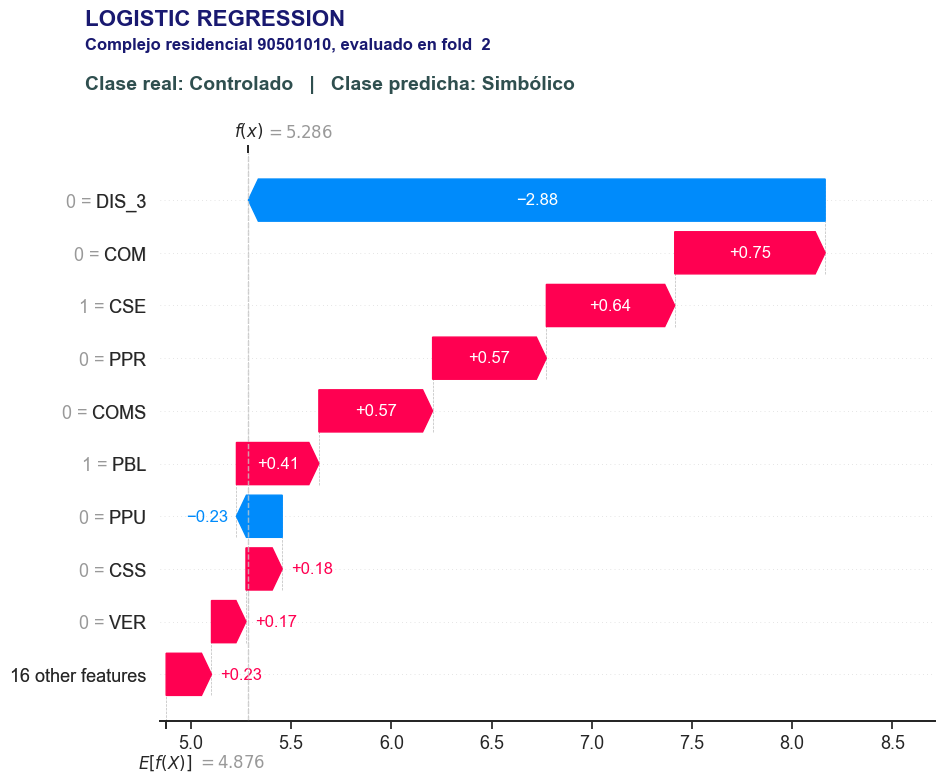

In [139]:
# Set sample ID
CC = 90501010
plot_shap_waterfall(cfg, LR_pred_info_df, LR_expected_shap_df, LR_shap_values_df, id_sample=CC, model_name="Logistic Regression", figsize=[10,8])

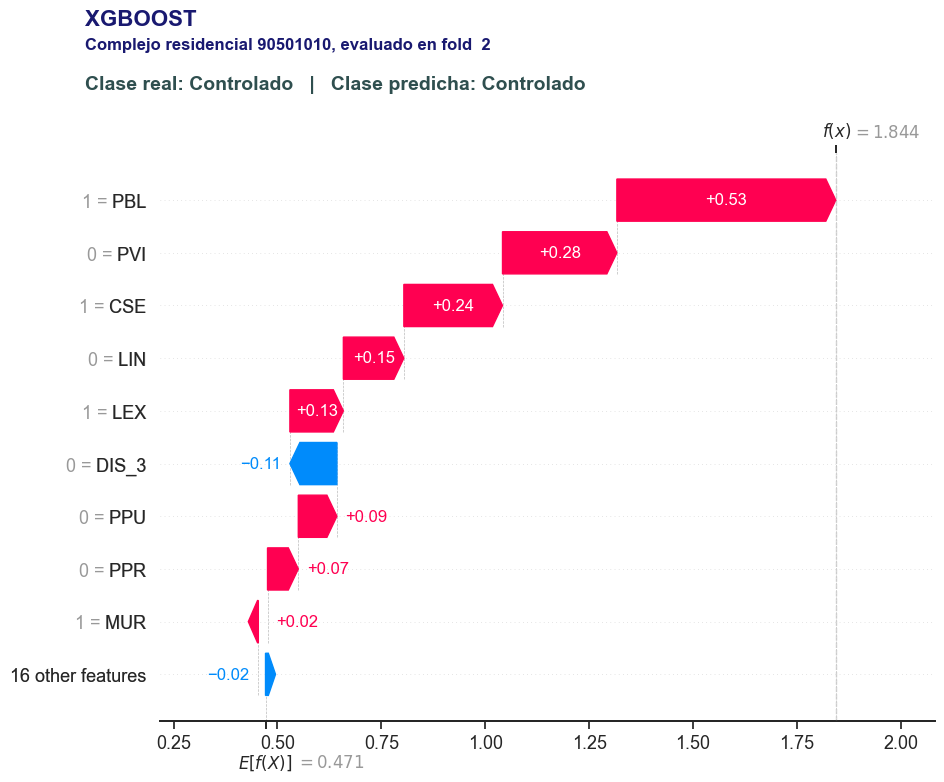

In [140]:
plot_shap_waterfall(cfg, XG_pred_info_df, XG_expected_shap_df, XG_shap_values_df, id_sample=CC, model_name="XGBoost", figsize=[10,8])